# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [2]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [6]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

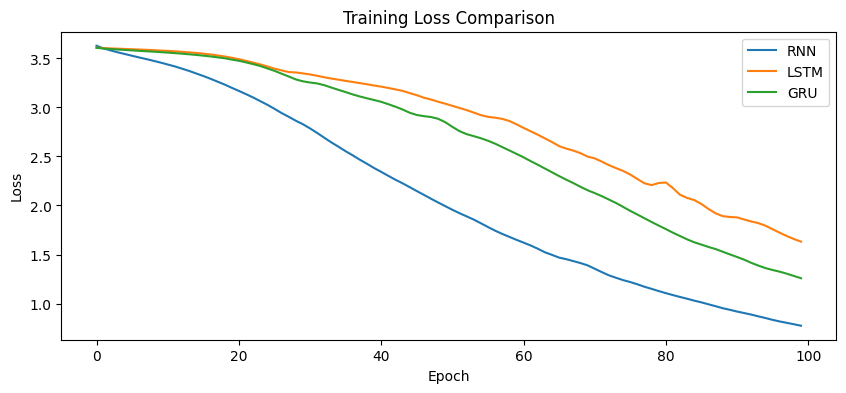

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [8]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [9]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "gru", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning learning transforming artificial intelligence intelligence
GRU : gru is faster simpler simpler than


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

**IMPLEMENTATION OF STUDENTS LEARNING TASKS**

**A. Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **epoche=200** + **Story line**

In [10]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
import re

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding
from tensorflow.keras.layers import SimpleRNN
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import GRU
from tensorflow.keras.layers import Dense

from sklearn.model_selection import train_test_split

In [11]:
corpus = '''
in a remote desert region a team of engineers established a research station
dedicated to studying renewable energy systems. the station was surrounded by
vast sand dunes and received sunlight throughout most of the year. researchers
believed that the location provided ideal conditions for testing advanced solar
technologies and energy storage solutions.

every morning technicians inspected rows of solar panels that stretched across
the landscape. they monitored power generation levels and recorded environmental
data including temperature wind speed and atmospheric conditions. the collected
information helped the team understand how different factors influenced energy
production and system efficiency.

one day the researchers noticed an unusual pattern in the performance data.
certain panels consistently generated more electricity than neighboring units
despite being exposed to similar environmental conditions. curious about the
difference the team conducted a detailed investigation and examined every
component of the high performing systems.

after several weeks of testing the engineers discovered that a newly developed
coating applied to the panel surfaces reduced dust accumulation and improved
light absorption. laboratory analysis confirmed that the material enhanced
performance without increasing manufacturing costs. the finding attracted
attention from energy companies interested in improving solar technology.

as interest grew organizations from different countries partnered with the
research station. experts in materials science environmental engineering and
data analytics collaborated to refine the coating and evaluate its long term
reliability. regular meetings allowed participants to exchange ideas share
results and coordinate future experiments.

the project soon expanded beyond solar energy applications. researchers began
exploring how similar surface treatments could improve the efficiency of water
purification systems and industrial equipment. machine learning models were
used to analyze experimental results and identify patterns that were difficult
to detect through traditional methods.

students from universities joined the initiative as interns and research
assistants. they gained experience working with advanced instruments collecting
field measurements and interpreting scientific data. many participants developed
a deeper appreciation for sustainable technologies and environmental innovation.

after years of development the team successfully introduced a new generation of
solar panels incorporating the improved coating technology. these systems
delivered higher energy output required less maintenance and operated effectively
in challenging environments. communities in remote regions benefited from
reliable access to clean electricity and reduced dependence on conventional
energy sources.

the success of the research station demonstrated the value of persistence
collaboration and technological innovation. it showed how scientific discovery
can contribute to sustainable development and address global energy challenges.
the engineers who initiated the project continued their work and inspired future
researchers to explore creative solutions for a rapidly changing world.
'''

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 271


In [13]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [15]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (380, 12)
y shape: (380,)


**VANILLA RNN**


In [16]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - accuracy: 0.0421 - loss: 5.5863
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0711 - loss: 5.3327
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0789 - loss: 5.1762 
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0816 - loss: 5.0660
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0974 - loss: 4.9643 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1132 - loss: 4.8404 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1289 - loss: 4.6942
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1632 - loss: 4.5130
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2395 - loss: 4.3284
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.2737 - loss: 4.1004
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.3211 - loss: 3.8639
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - acc

**LSTM**: Long Short-Term Memory (LSTM) is an advanced type of Recurrent Neural Network (RNN) designed to process sequential data.

In [ ]:
from tensorflow.keras.layers import LSTM

lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - accuracy: 0.0242 - loss: 5.4125    
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0667 - loss: 5.2993
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0606 - loss: 5.1272
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0515 - loss: 5.0364
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.9896
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0636 - loss: 4.9436
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.0727 - loss: 4.9058
Epoch 8/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0758 - loss: 4.8765
Epoch 9/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.7985
Epoch 10/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.0727 - loss: 4.7194
Epoch 11/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.0758 - loss: 4.6273 
Epoch 12/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms

**GRU**

In [17]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0395 - loss: 5.5983
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0737 - loss: 5.5340
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0605 - loss: 5.3204
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0763 - loss: 5.1970
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0605 - loss: 5.1297
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0789 - loss: 5.0802
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0974 - loss: 5.0224
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1184 - loss: 4.9223
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0895 - loss: 4.7890
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1184 - loss: 4.6324
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1395 - loss: 4.4665
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

##Accuracy Comparison

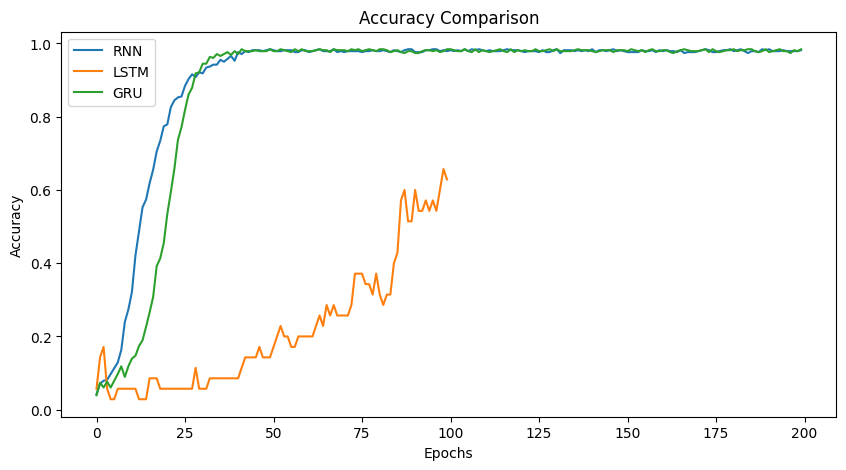

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

##Loss Comparison

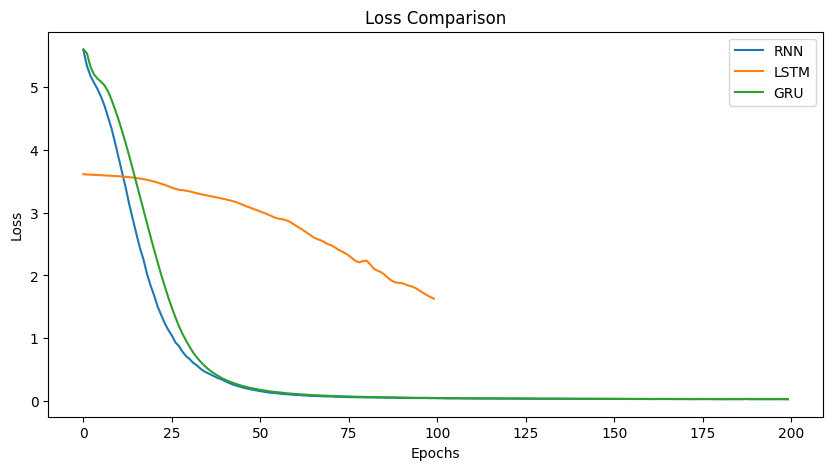

In [19]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

TEXT GENERATION:

In [20]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

TESTING

In [32]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "the engineer",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "the engineer",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "the engineer",
                    10))


RNN Output:
the engineer project soon expanded beyond solar energy applications researchers began an

LSTM Output:
the engineer and team team research station systems systems systems systems environmental

GRU Output:
the engineer engineers who initiated the project continued their work and inspired


Next word prediction

In [33]:
seed = "one solar"

print(generate_text(
    lstm_model,
    seed,
    10
))

one solar team research research systems systems systems systems researchers researchers environmental


Compare Generate Text Quality

In [34]:
prompt = "laborataory"

print(generate_text(rnn_model,prompt,10))
print(generate_text(lstm_model,prompt,10))
print(generate_text(gru_model,prompt,10))

laborataory to detect through traditional methods the project soon expanded beyond
laborataory team team team research station systems systems systems researchers researchers
laborataory years of development the team successfully introduced a new generation


Random Prompt Technique

In [24]:
print(generate_text(
    lstm_model,
    "research",
    10
))

research team team research station systems systems systems researchers researchers environmental


In [35]:
print(generate_text(
    gru_model,
    "energy",
    10
))

energy sources appreciation for sustainable technologies and environmental innovation it showed


In [36]:
print(generate_text(
    lstm_model,
    "energy",
    10
))

energy team team research research systems systems systems systems researchers environmental


In [37]:
print(generate_text(
    lstm_model,
    "the engineers",10
))

the engineers team team research research systems systems systems systems researchers environmental


In [38]:
print(generate_text(
    gru_model,
    "the engineers",10
))

the engineers who initiated the project continued their work and inspired future


In [39]:
print(generate_text(
    rnn_model,
    "the engineers",10
))

the engineers who initiated the project continued their work and inspired future


**B.  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **Song Lyrics**

In [40]:
corpus = '''
thick clouds covered the mountain range as members of a rescue team prepared
for another challenging day. the region was known for unpredictable weather
steep cliffs and narrow trails that attracted hikers from many places. every
morning the team reviewed weather reports checked equipment and planned patrol
routes to ensure visitor safety.

one afternoon an emergency signal was received from a remote valley located far
from the nearest shelter. the message indicated that a group of hikers had become
stranded after a sudden storm blocked their route. without delay the rescue team
organized a response and began the difficult journey toward the affected area.

after several hours of travel the rescuers located the hikers near a rocky ridge.
strong winds and heavy rainfall had made movement extremely dangerous. the team
carefully distributed supplies provided medical assistance and established a safe
path back toward lower ground. communication specialists remained in contact with
the base station to coordinate additional support.

as reports of the operation spread local authorities became interested in
improving emergency response capabilities. experts from different organizations
collaborated to study the challenges faced during mountain rescues. they shared
data exchanged recommendations and developed new strategies for future missions.

months of evaluation produced important findings. analysts discovered that
advanced weather prediction systems could significantly improve response times.
they also found that better communication equipment reduced delays during critical
situations. these improvements helped rescuers make more informed decisions in
difficult environments.

the safety initiative continued to expand and attracted support from government
agencies educational institutions and outdoor recreation groups. technologies
such as satellite mapping drone surveillance and machine learning were introduced
to analyze terrain conditions and identify potential risks. the integration of
these tools improved planning and operational efficiency.

students and volunteers joined training programs to learn about emergency
preparedness and disaster management. they gained practical experience in first
aid navigation risk assessment and teamwork. many participants developed a strong
interest in public service and community safety.

after several years the rescue organization became a model for mountain safety
programs across the region. accident rates decreased response times improved and
more visitors were able to enjoy outdoor activities with confidence. communities
benefited from stronger emergency services and increased awareness of safety
practices.

the success of the program highlighted the importance of preparation cooperation
and dedication. it demonstrated how effective planning and continuous learning
can protect lives during difficult situations. the rescue team continued to serve
the region and inspired future generations to contribute to public safety and
community welfare.
'''

In [41]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 270


In [42]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [44]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (375, 13)
y shape: (375,)


*Vanila RNN*

In [45]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history_200 = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.0373 - loss: 5.5783
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0560 - loss: 5.3560 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0427 - loss: 5.2019     
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0747 - loss: 5.0792 
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0987 - loss: 4.9647 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1253 - loss: 4.8383 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1760 - loss: 4.6890 
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2080 - loss: 4.5003 
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2880 - loss: 4.2800 
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3360 - loss: 4.0515 
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4000 - loss: 3.8176 
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accur

*LSTM*

In [46]:
lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history_200 = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0373 - loss: 5.5969
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0640 - loss: 5.5149
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0533 - loss: 5.3287
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0507 - loss: 5.2147
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0453 - loss: 5.1624
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0560 - loss: 5.1089
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0613 - loss: 5.0332
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0667 - loss: 4.9627
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.0667 - loss: 4.8813
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0773 - loss: 4.7951
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0853 - loss: 4.6988
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step -

*GRU*

In [47]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history_200 = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0240 - loss: 5.5961
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0773 - loss: 5.5474
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0587 - loss: 5.3647
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0533 - loss: 5.2353
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0507 - loss: 5.1684
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0933 - loss: 5.0953
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0907 - loss: 5.0327
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0960 - loss: 4.9403
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1040 - loss: 4.7914
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1093 - loss: 4.6234
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1200 - loss: 4.4354
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

ACCURACY

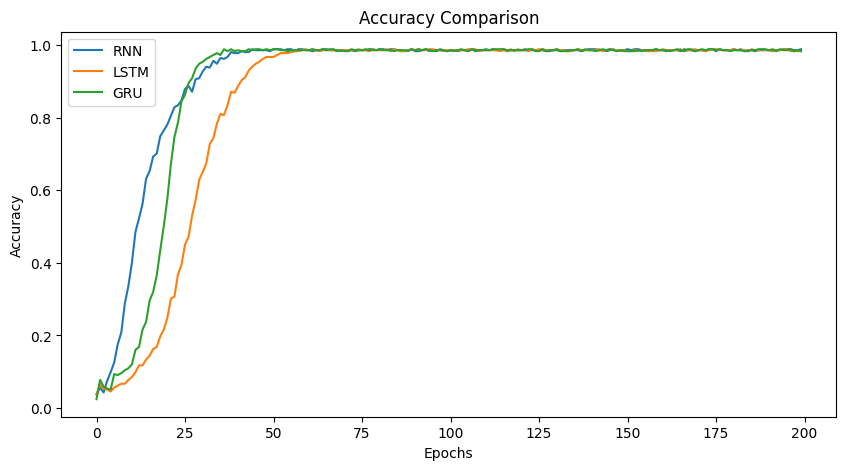

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    rnn_history_200.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history_200.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history_200.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

LOSS

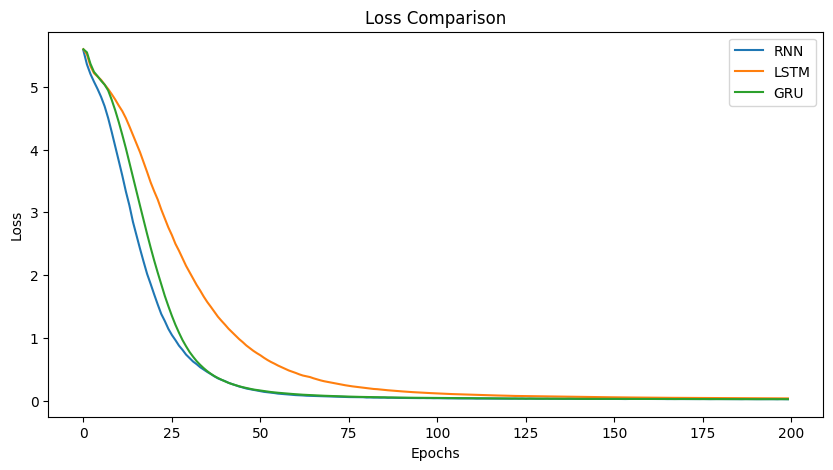

In [49]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history_200.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history_200.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history_200.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

**TEXT GENERATION**

In [50]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

*TESTING*

In [54]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "weather report",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "weather report",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "weather report",
                    10))


RNN Output:
weather report reports of the operation spread local authorities became interested in

LSTM Output:
weather report prediction systems could significantly improve response times times improved and

GRU Output:
weather report prediction systems could significantly improve response times improved and established


*NEXT WORD PREDICTION*

In [56]:
seed = "calling"

print(generate_text(
    lstm_model,
    seed,
    10
))

calling across the region accident rates decreased response times improved and


*COMPARE GENERATE TEXT QUALITY*

In [57]:
prompt = "rescue"

print("RNN-Vanilla--->",generate_text(rnn_model,prompt,20))
print("LSTM--->",generate_text(lstm_model,prompt,10))
print("GRU--->",generate_text(gru_model,prompt,10))

RNN-Vanilla---> rescue a response and began the difficult journey toward the affected area rates decreased response times improved and heavy rainfall had
LSTM---> rescue and volunteers joined training programs to learn emergency safety government
GRU---> rescue team and narrow trails that attracted hikers from many places


*RANDOM PROMPT TECHNIQUE*

In [58]:
print("LSTM",generate_text(
    lstm_model,
    "team",
    10
))
print("RNN-VANILLA:",generate_text(
    rnn_model,
    "team",
    10
))
print("GRU:",generate_text(
    gru_model,
    "team",
    10
))

LSTM team weather prediction systems could significantly improve response times times improved
RNN-VANILLA: team the safety initiative continued to expand and attracted support from
GRU: team tools improved planning and operational efficiency from government had become


In [59]:
print("LSTM:",generate_text(
    lstm_model,
    "rescue",
    10
))
print("RNN-VANILLA:",generate_text(
    rnn_model,
    "rescue",
    10
))
print("GRU:",generate_text(
    gru_model,
    "rescue",
    10
))

LSTM: rescue and volunteers joined training programs to learn emergency safety government
RNN-VANILLA: rescue a response and began the difficult journey toward the affected
GRU: rescue team and narrow trails that attracted hikers from many places


**C.  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **Shakespeare text**

In [60]:
corpus = '''
the small office remained brightly lit long after sunset as a team of game
developers worked on their most ambitious project. the studio had been founded
by a group of friends who shared a passion for storytelling design and technology.
every day artists programmers and writers collaborated to transform ideas into
interactive experiences for players around the world.

one evening a developer proposed an unusual gameplay mechanic that allowed
players to influence the environment through their decisions. the concept was
different from anything the team had previously created. curious about its
potential the developers built a prototype and began testing how the mechanic
could affect exploration challenges and character interactions.

early experiments produced encouraging results. players responded positively to
the freedom offered by the new system and discovered creative ways to solve
problems within the game world. designers carefully observed feedback and made
adjustments to improve balance progression and overall enjoyment.

as news of the project spread gaming communities became interested in the
upcoming release. content creators shared previews and discussed potential
features with their audiences. the development team monitored discussions
collected suggestions and evaluated ideas that could enhance the final product.

months of development led to significant improvements. artists created detailed
environments while writers expanded the story with memorable characters and
meaningful choices. programmers optimized performance and introduced new systems
that increased immersion. each department contributed to building a cohesive
experience.

the project continued to grow and attracted support from publishers investors
and industry professionals. advanced technologies such as procedural generation
motion capture and artificial intelligence were incorporated into the development
process. these tools improved efficiency and enabled the creation of more dynamic
content.

students and aspiring developers joined the studio through internship programs.
they learned how to design game mechanics create digital assets write code and
test software. working alongside experienced professionals provided valuable
insights into the challenges of game development.

after several years the game was finally released to the public. players praised
its innovative mechanics engaging story and artistic presentation. strong sales
and positive reviews allowed the studio to expand its operations and begin work
on future projects.

the success of the game highlighted the importance of creativity collaboration
and persistence. it demonstrated how a small group of dedicated individuals
could transform a simple idea into a widely recognized achievement. the studio
continued to develop new experiences and inspired future generations of creators
to pursue their passion for interactive entertainment.
'''

In [62]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 255


In [63]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [64]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (363, 13)
y shape: (363,)


**VANILLA RNN**

In [65]:
rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 153ms/step - accuracy: 0.0193 - loss: 5.5069
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.2649
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.1201
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.0198
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0744 - loss: 4.9326 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1019 - loss: 4.8242 
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1240 - loss: 4.6859 
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1350 - loss: 4.5495 
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1901 - loss: 4.3516 
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2452 - loss: 4.1259
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3361 - loss: 3.8722 
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - a

**LSTM**

In [66]:
lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0441 - loss: 5.5343
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0689 - loss: 5.3875
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.2093
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0661 - loss: 5.1280
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.0993
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0661 - loss: 5.0736
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0799 - loss: 5.0374
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0826 - loss: 4.9915
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0716 - loss: 4.9259
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1019 - loss: 4.8529
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0937 - loss: 4.7662
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

**GRU**

In [67]:
gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.0413 - loss: 5.5388
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0661 - loss: 5.4894
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0661 - loss: 5.3145
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0661 - loss: 5.1271
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.0799 - loss: 5.0672
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0716 - loss: 5.0128
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0964 - loss: 4.9342
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0992 - loss: 4.7948
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.1074 - loss: 4.6329
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.1157 - loss: 4.4729
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1322 - loss: 4.3321
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 

*Accuracy Comparison*

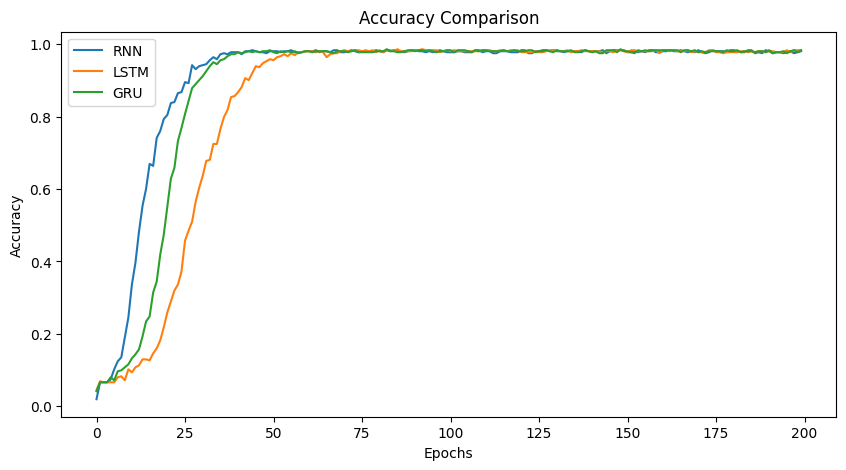

In [68]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*Loss Comparison*

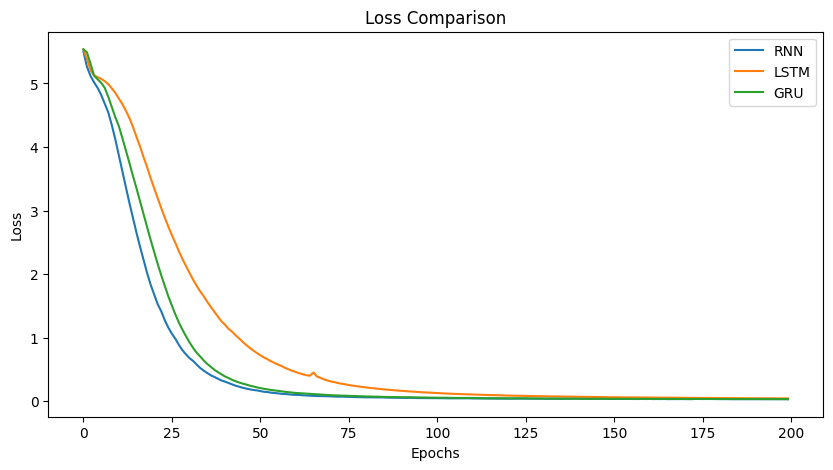

In [69]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

**Testing and Text Generation**

In [70]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [71]:
print("\nRNN Output:")
print(generate_text(rnn_model,
                    "game player",
                    10))

print("\nLSTM Output:")
print(generate_text(lstm_model,
                    "game player",
                    10))

print("\nGRU Output:")
print(generate_text(gru_model,
                    "game player",
                    10))


RNN Output:
game player into the small office remained brightly lit long after sunset

LSTM Output:
game player these tools improved efficiency and enabled the creation of more

GRU Output:
game player increased immersion each department contributed to building a cohesive recognized


In [72]:
seed = "developer"

print(generate_text(
    lstm_model,
    seed,
    10
))

developer and aspiring developers joined the studio through internship programs programs


In [73]:
prompt = "technology"

print(generate_text(rnn_model,prompt,10))
print(generate_text(lstm_model,prompt,10))
print(generate_text(gru_model,prompt,10))

technology to pursue their passion for interactive entertainment for players around
technology to pursue their passion for interactive entertainment for the design
technology news of the project spread gaming communities became interested in


In [74]:
print(generate_text(
    lstm_model,
    "story design",
    10
))

story design and aspiring developers joined the studio internship programs programs dynamic


In [75]:
print(generate_text(
    gru_model,
    "story design",
    10
))

story design and aspiring developers joined the studio through internship programs programs


In [76]:
print(generate_text(
    lstm_model,
    "story design",
    10
))

story design and aspiring developers joined the studio internship programs programs dynamic


**D. Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **chatbot data**

In [77]:
corpus = '''
at the center of the continent stood a library larger than any city marketplace.
its halls stretched for kilometers and contained millions of books manuscripts
maps and records collected over many centuries. scholars travelers historians
and inventors visited the library in search of knowledge that could not be found
anywhere else.

every section of the library served a different purpose. one wing preserved
ancient histories while another stored scientific observations gathered from
distant regions. librarians carefully organized information and ensured that
valuable documents remained protected from damage and loss.

one year the librarians noticed an unusual problem. several manuscripts from
different collections appeared to reference the same forgotten location. although
the texts were written in different languages and originated from distant places
they described similar landmarks events and traditions. the discovery attracted
the attention of researchers throughout the continent.

teams of scholars began studying the manuscripts in greater detail. linguists
translated unfamiliar symbols historians compared timelines and geographers
analyzed maps contained within the records. each group contributed unique
insights that gradually revealed connections between the documents.

months of investigation led to important findings. researchers discovered that
the manuscripts described a network of trade routes that had disappeared centuries
earlier. these routes once connected major cities and enabled the exchange of
goods knowledge and culture across vast distances. many details had been forgotten
over time and survived only within scattered records.

the project expanded as new evidence emerged. advanced cataloging systems were
introduced to manage growing collections of information. mathematical models
were used to identify patterns while digital archives preserved fragile materials.
the combination of traditional scholarship and modern technology accelerated
research efforts.

students traveled from many regions to participate in the initiative. they learned
how to analyze historical sources verify information organize archives and present
research findings. experienced librarians guided them through complex collections
and encouraged critical thinking.

after several years the research teams successfully reconstructed much of the
ancient trade network. historians gained a clearer understanding of economic
development while governments used the findings to protect historical sites.
many communities rediscovered important aspects of their cultural heritage.

the success of the project demonstrated the value of preserving knowledge and
encouraging collaboration. it showed that information collected across generations
could reveal insights that no single document contained. the grand library
continued to serve as a center of learning and inspired future scholars to
explore the connections between history culture and discovery.
'''

In [78]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 248


In [79]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [81]:
X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (360, 13)
y shape: (360,)


**VANILLA RNN**

In [82]:
rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.0167 - loss: 5.4830
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0500 - loss: 5.2290 
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0667 - loss: 5.0995     
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0722 - loss: 4.9673 
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0750 - loss: 4.8814 
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1278 - loss: 4.7716
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1944 - loss: 4.6148
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2194 - loss: 4.4696
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2167 - loss: 4.2986 
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2667 - loss: 4.0847
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3389 - loss: 3.8680 
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step

**LSTM**

In [84]:
lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0361 - loss: 5.5091
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0556 - loss: 5.4041
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0556 - loss: 5.1938
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0472 - loss: 5.1136
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0611 - loss: 5.0734
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0611 - loss: 5.0309
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.0694 - loss: 4.9774
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0583 - loss: 4.9042
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0667 - loss: 4.8242
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0778 - loss: 4.7422
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0972 - loss: 4.6418
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step 

**GRU**

In [85]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.0222 - loss: 5.5121
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0694 - loss: 5.4661
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0556 - loss: 5.2915
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0556 - loss: 5.1179
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0750 - loss: 5.0524
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1000 - loss: 5.0034
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1000 - loss: 4.9410
Epoch 8/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1000 - loss: 4.8602
Epoch 9/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1083 - loss: 4.7359
Epoch 10/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1250 - loss: 4.5794
Epoch 11/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1417 - loss: 4.3967
Epoch 12/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

*ACCURACY*

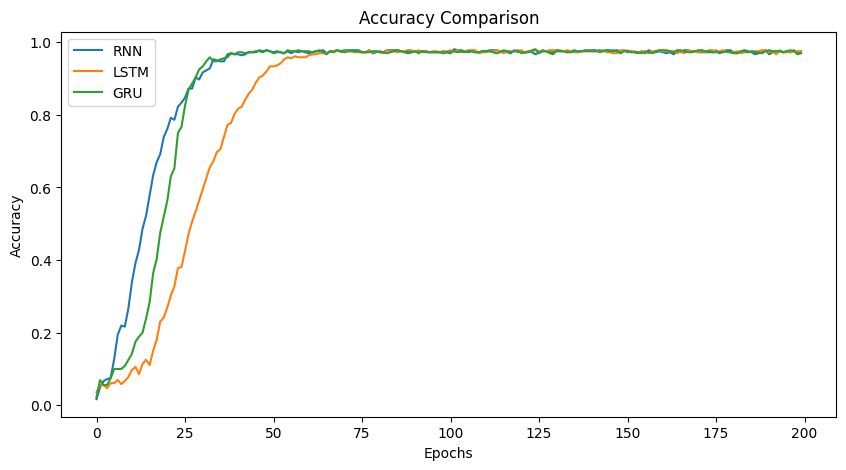

In [86]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*LOSS*

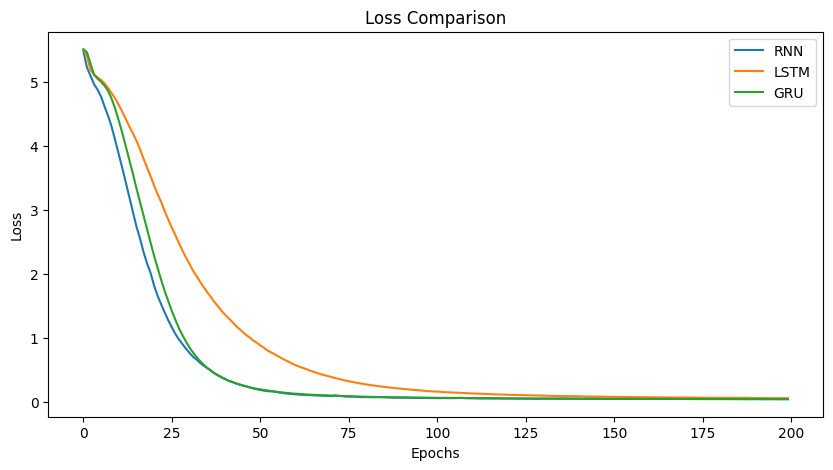

In [87]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

*TEXT GENERATION AND TESTING*

In [88]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [93]:
print("\nRNN Output:")
print(generate_text(
    rnn_model,
    "at the center of the continent",
    32
))

print("\nLSTM Output:")
print(generate_text(
    lstm_model,
    "at the center of the continent",
    32
))

print("\nGRU Output:")
print(generate_text(
    gru_model,
    "at the center of the continent",
    32
))


RNN Output:
at the center of the continent stood a library larger than any city marketplace began studying the manuscripts in greater detail linguists learned stored scientific observations gathered from a different purpose one wing preserved fragile materials an unusual

LSTM Output:
at the center of the continent stood a library larger than any city marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace places places places places places places places places places marketplace marketplace marketplace

GRU Output:
at the center of the continent stood a library larger than any city marketplace marketplace city marketplace marketplace city city marketplace marketplace city city marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace marketplace


In [94]:
seed = "after several years the reasearch"

print(generate_text(
    lstm_model,
    seed
))

after several years the reasearch research teams successfully reconstructed much of the library library different


In [95]:
prompt = "trade network"

print(generate_text(rnn_model,prompt))
print(generate_text(lstm_model,prompt))
print(generate_text(gru_model,prompt))

trade network historians gained a clearer understanding of economic led to important
trade network historians gained a clearer clearer understanding of economic economic economic
trade network historians gained a clearer understanding of economic economic economic economic


In [96]:
print(generate_text(
    lstm_model,
    "the value of knowledege",
    10
))
print(generate_text(
    gru_model,
    "the value of knowledege",
    10
))
print(generate_text(
    lstm_model,
    "the value of knowledege",
    10
))

the value of knowledege traditional scholarship and modern technology accelerated accelerated accelerated from distant
the value of knowledege the project demonstrated the value of preserving knowledge and culture
the value of knowledege traditional scholarship and modern technology accelerated accelerated accelerated from distant


**E.  Replace corpus with our own Paragaph** + **Increasing Embedding** + **Hidden units 64 ---> 128** + **Generation of 10 words instead of 5** + **Epoche=200** + **PDF TEXT**

In [98]:
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 347.3/347.3 kB 6.9 MB/s eta 0:00:00


In [99]:
from pypdf import PdfReader

reader = PdfReader("smart_city.pdf")

corpus = ""

for page in reader.pages:
    text = page.extract_text()

    if text:
        corpus += text + " "

print(corpus[:4000])

Text Generation Corpus: Smart Port City
Before sunrise the harbor was already active with cargo vessels, fishing boats, and transport ferries
moving through the water. The coastal city had grown into one of the most important trading centers
in the region, connecting distant communities through commerce and transportation. Every day
thousands of workers coordinated operations to ensure that goods and passengers reached their
destinations. Several years earlier city planners had launched an ambitious initiative to transform
the harbor into a smart port. Traditional processes were replaced with digital systems capable of
tracking shipments, monitoring equipment, and managing traffic in real time. The goal was to
improve efficiency while reducing delays and environmental impact. One morning operators noticed
unusual congestion patterns developing near the main shipping channels. Although weather
conditions were favorable, vessel movement had slowed significantly. Analysts began investigat

In [103]:
tokenizer = Tokenizer()

tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1

print("Vocabulary Size:", total_words)

Vocabulary Size: 305


In [104]:
input_sequences = []

for line in corpus.split('\n'):

    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):

        n_gram_seq = token_list[:i+1]

        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)

input_sequences = pad_sequences(
    input_sequences,
    maxlen=max_len,
    padding='pre'
)

In [105]:

X = input_sequences[:, :-1]

y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (421, 16)
y shape: (421,)


**VANILLA RNN**

In [106]:
rnn_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    SimpleRNN(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_history = rnn_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("Vanilla RNN Training Completed")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.0143 - loss: 5.7139
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0523 - loss: 5.5185     
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0499 - loss: 5.3398 
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0808 - loss: 5.1785 
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.0950 - loss: 5.0423 
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.1045 - loss: 4.8774
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1639 - loss: 4.6985 
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2209 - loss: 4.4703 
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2969 - loss: 4.2239 
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3919 - loss: 3.9797 
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4347 - loss: 3.7218 
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/s

**LSTM**

In [107]:
lstm_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    LSTM(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_history = lstm_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("LSTM Training Completed")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0190 - loss: 5.7165
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0499 - loss: 5.5868
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0404 - loss: 5.4563
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0546 - loss: 5.3698
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0475 - loss: 5.3285
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0523 - loss: 5.2905
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0546 - loss: 5.2369
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0546 - loss: 5.1704
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0570 - loss: 5.0942
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0713 - loss: 5.0106
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0713 - loss: 4.9165
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy:

**GRU**

In [108]:
from tensorflow.keras.layers import GRU

gru_model = Sequential([

    Embedding(
        total_words,
        128,
        input_length=max_len-1
    ),

    GRU(128),

    Dense(
        total_words,
        activation='softmax'
    )
])

gru_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_history = gru_model.fit(
    X,
    y,
    epochs=200,
    verbose=1
)

print("GRU Training Completed")

Epoch 1/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.0261 - loss: 5.7188
Epoch 2/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0594 - loss: 5.6726
Epoch 3/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0499 - loss: 5.5120
Epoch 4/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0689 - loss: 5.4000
Epoch 5/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0784 - loss: 5.2902
Epoch 6/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0808 - loss: 5.2426
Epoch 7/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0665 - loss: 5.1718
Epoch 8/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0689 - loss: 5.0698
Epoch 9/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0689 - loss: 4.9307
Epoch 10/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0879 - loss: 4.7287
Epoch 11/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.0998 - loss: 4.5293
Epoch 12/200
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy:

*ACCURACY*

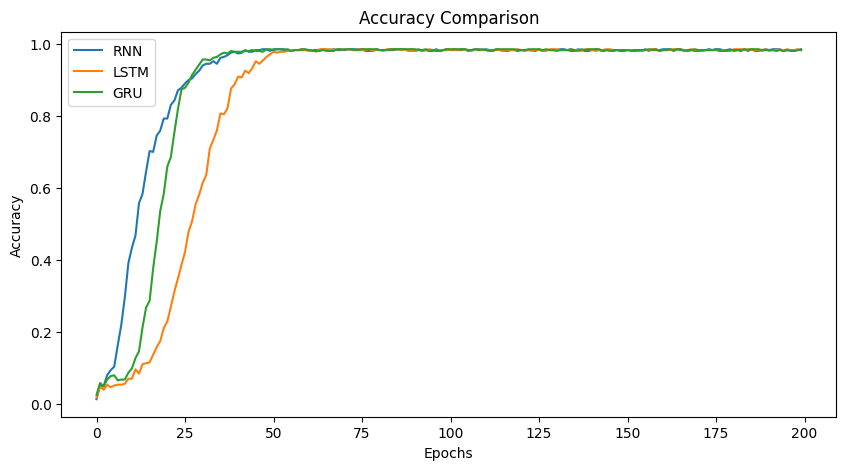

In [109]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['accuracy'],
    label='RNN'
)

plt.plot(
    lstm_history.history['accuracy'],
    label='LSTM'
)

plt.plot(
    gru_history.history['accuracy'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.legend()

plt.show()

*LOSS*

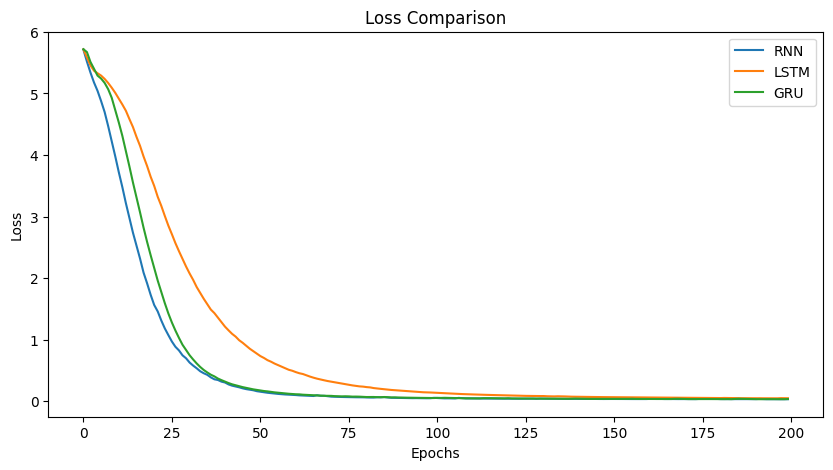

In [110]:
plt.figure(figsize=(10,5))

plt.plot(
    rnn_history.history['loss'],
    label='RNN'
)

plt.plot(
    lstm_history.history['loss'],
    label='LSTM'
)

plt.plot(
    gru_history.history['loss'],
    label='GRU'
)

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss Comparison")
plt.legend()

plt.show()

*TEXT GENERATION and TESTING*

In [111]:
def generate_text(model, seed_text, next_words=10):

    for _ in range(next_words):

        token_list = tokenizer.texts_to_sequences(
            [seed_text]
        )[0]

        token_list = pad_sequences(
            [token_list],
            maxlen=max_len-1,
            padding='pre'
        )

        predicted = np.argmax(
            model.predict(
                token_list,
                verbose=0
            ),
            axis=-1
        )[0]

        output_word = ""

        for word, index in tokenizer.word_index.items():

            if index == predicted:

                output_word = word
                break

        seed_text += " " + output_word

    return seed_text

In [115]:
print("\nRNN Output:")
print(generate_text(
    rnn_model,
    "the smart port",
    10))

print("\nLSTM Output:")
print(generate_text(
    lstm_model,
    "the smart port",
    10))

print("\nGRU Output:")
print(generate_text(
    gru_model,
    "the smart port",
    10))


RNN Output:
the smart port a smart port traditional processes were replaced with digital systems

LSTM Output:
the smart port ecosystem students and young professionals participated in training programs associated

GRU Output:
the smart port ecosystem students and young professionals participated in training programs associated


In [116]:
seed = "after several years"

print("\nRNN:")
print(generate_text(rnn_model, seed, 15))

print("\nLSTM:")
print(generate_text(lstm_model, seed, 15))

print("\nGRU:")
print(generate_text(gru_model, seed, 15))


RNN:
after several years the city continued to invest in modernization efforts and inspired future generations to build smarter

LSTM:
after several years earlier city planners had launched an ambitious initiative initiative to transform transform centers centers centers

GRU:
after several years the smart port became an international the port infrastructure after several years the coastal coastal


In [117]:
seed = "the modernization effort"

print("\nRNN Output:")
print(generate_text(rnn_model, seed, 10))

print("\nLSTM Output:")
print(generate_text(lstm_model, seed, 10))

print("\nGRU Output:")
print(generate_text(gru_model, seed, 10))


RNN Output:
the modernization effort continued to expand and attracted support from different organizations worked

LSTM Output:
the modernization effort continued to expand and attracted support from support from trade

GRU Output:
the modernization effort continued to invest in modernization efforts and inspired future generations


 Conclusion

In this project, we implemented and compared three recurrent neural network architectures for text generation: Vanilla RNN, LSTM, and GRU. A custom Smart City corpus was used to train the models and learn sequential language patterns for next-word prediction.

The text data was preprocessed through tokenization, sequence generation, and padding before being used for training. Each model was trained using an embedding layer followed by its respective recurrent architecture and a softmax output layer for word prediction.

The Vanilla RNN successfully learned basic sentence structures and frequently occurring word patterns. However, it struggled to maintain context over longer sequences due to the vanishing gradient problem. LSTM demonstrated improved performance by effectively retaining long-term dependencies through its gating mechanisms, resulting in more coherent and contextually meaningful text generation. GRU achieved performance comparable to LSTM while using a simpler architecture and fewer parameters, leading to faster training and efficient learning.

Training accuracy and loss curves showed that LSTM and GRU generally converged more effectively than the Vanilla RNN. Generated text samples further highlighted the ability of LSTM and GRU to preserve contextual information and produce more natural sentence continuations.

Overall, this project provided practical experience with sequence modeling, text preprocessing, language generation, and recurrent neural network architectures. The comparison demonstrated that while Vanilla RNN can learn simple patterns, LSTM and GRU are better suited for text generation tasks that require understanding of longer contextual dependencies.
